<a href="https://colab.research.google.com/github/HarshithDevX/2420080016_ML/blob/main/2420080016_week_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

NEURAL NETWORKS FROM SCRATCH - XOR PROBLEM

1. PERCEPTRON
AND: [0 0 0 1]
OR: [0 1 1 1]
XOR: [1 1 0 0]

2. TWO-LAYER NEURAL NETWORK
XOR Result: [0 1 1 0]

3. COMPARISON
Hidden neurons: 2 -> Accuracy: 50%
Hidden neurons: 4 -> Accuracy: 100%
Hidden neurons: 8 -> Accuracy: 100%


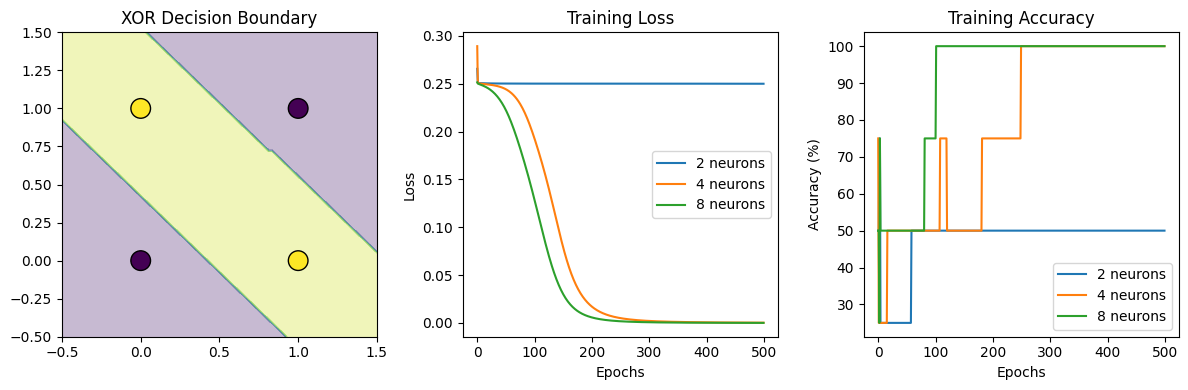


SUMMARY
Perceptron: Works for AND/OR but fails for XOR
2-Layer NN: Successfully learns XOR
More hidden neurons -> Faster learning
All implemented from scratch using NumPy


In [1]:
# In-Lab
import numpy as np
import matplotlib.pyplot as plt

class Perceptron:
    def __init__(self):
        self.weights = None
        self.bias = 0

    def train(self, X, y, epochs=20):
        self.weights = np.zeros(X.shape[1])
        for _ in range(epochs):
            for i in range(len(X)):
                prediction = 1 if np.dot(X[i], self.weights) + self.bias >= 0 else 0
                error = y[i] - prediction
                self.weights += error * X[i]
                self.bias += error

    def predict(self, X):
        return np.array([1 if np.dot(x, self.weights) + self.bias >= 0 else 0 for x in X])


class TwoLayerNN:
    def __init__(self):
        self.W1 = np.random.randn(2, 4) * 0.5
        self.b1 = np.zeros(4)
        self.W2 = np.random.randn(4, 1) * 0.5
        self.b2 = np.zeros(1)

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def train(self, X, y, epochs=5000):
        y = y.reshape(-1, 1)
        for _ in range(epochs):
            hidden = self.sigmoid(np.dot(X, self.W1) + self.b1)
            output = self.sigmoid(np.dot(hidden, self.W2) + self.b2)

            output_error = output - y
            hidden_error = output_error.dot(self.W2.T) * hidden * (1 - hidden)

            self.W2 -= 0.5 * hidden.T.dot(output_error)
            self.b2 -= 0.5 * np.sum(output_error, axis=0)
            self.W1 -= 0.5 * X.T.dot(hidden_error)
            self.b1 -= 0.5 * np.sum(hidden_error, axis=0)

    def predict(self, X):
        hidden = self.sigmoid(np.dot(X, self.W1) + self.b1)
        output = self.sigmoid(np.dot(hidden, self.W2) + self.b2)
        return (output > 0.5).astype(int).flatten()


class SimpleKeras:
    def __init__(self, hidden_neurons):
        self.W1 = np.random.randn(2, hidden_neurons) * 0.5
        self.b1 = np.zeros(hidden_neurons)
        self.W2 = np.random.randn(hidden_neurons, 1) * 0.5
        self.b2 = np.zeros(1)
        self.losses = []
        self.accuracies = []

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def fit(self, X, y, epochs=1000):
        y = y.reshape(-1, 1)
        for _ in range(epochs):
            hidden = self.sigmoid(np.dot(X, self.W1) + self.b1)
            output = self.sigmoid(np.dot(hidden, self.W2) + self.b2)

            loss = np.mean((y - output) ** 2)
            self.losses.append(loss)

            acc = np.mean((output > 0.5) == y) * 100
            self.accuracies.append(acc)

            d_output = output - y
            d_hidden = d_output.dot(self.W2.T) * hidden * (1 - hidden)

            self.W2 -= 0.5 * hidden.T.dot(d_output)
            self.b2 -= 0.5 * np.sum(d_output)
            self.W1 -= 0.5 * X.T.dot(d_hidden)
            self.b1 -= 0.5 * np.sum(d_hidden, axis=0)

    def predict(self, X):
        hidden = self.sigmoid(np.dot(X, self.W1) + self.b1)
        return (self.sigmoid(np.dot(hidden, self.W2) + self.b2) > 0.5).astype(int).flatten()


X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_and = np.array([0, 0, 0, 1])
y_or = np.array([0, 1, 1, 1])
y_xor = np.array([0, 1, 1, 0])

print("=" * 60)
print("NEURAL NETWORKS FROM SCRATCH - XOR PROBLEM")
print("=" * 60)

print("\n1. PERCEPTRON")
p = Perceptron()

p.train(X, y_and)
print("AND:", p.predict(X))

p.train(X, y_or)
print("OR:", p.predict(X))

p.train(X, y_xor)
print("XOR:", p.predict(X))

print("\n2. TWO-LAYER NEURAL NETWORK")
nn = TwoLayerNN()
nn.train(X, y_xor)
print("XOR Result:", nn.predict(X))

print("\n3. COMPARISON")

for neurons in [2, 4, 8]:
    model = SimpleKeras(neurons)
    model.fit(X, y_xor, epochs=1000)
    pred = model.predict(X)
    accuracy = np.mean(pred == y_xor) * 100
    print(f"Hidden neurons: {neurons} -> Accuracy: {accuracy:.0f}%")

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
model_viz = SimpleKeras(4)
model_viz.fit(X, y_xor, epochs=1000)

xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 100), np.linspace(-0.5, 1.5, 100))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = model_viz.predict(grid).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=y_xor, s=200, edgecolor='black')
plt.title("XOR Decision Boundary")

plt.subplot(1, 3, 2)
for neurons in [2, 4, 8]:
    m = SimpleKeras(neurons)
    m.fit(X, y_xor, epochs=500)
    plt.plot(m.losses, label=f"{neurons} neurons")
plt.title("Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 3, 3)
for neurons in [2, 4, 8]:
    m = SimpleKeras(neurons)
    m.fit(X, y_xor, epochs=500)
    plt.plot(m.accuracies, label=f"{neurons} neurons")
plt.title("Training Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.legend()

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
print("Perceptron: Works for AND/OR but fails for XOR")
print("2-Layer NN: Successfully learns XOR")
print("More hidden neurons -> Faster learning")
print("All implemented from scratch using NumPy")

In [3]:
#Post Lab
import numpy as np
from sklearn.datasets import load_iris
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

class NeuralNetwork:
    def __init__(self, input_size, hidden_size, output_size, lr=0.01, optimizer="sgd", dropout=0.0, l2=0.0):
        self.W1 = np.random.randn(input_size, hidden_size) * 0.5
        self.b1 = np.zeros(hidden_size)
        self.W2 = np.random.randn(hidden_size, output_size) * 0.5
        self.b2 = np.zeros(output_size)

        self.lr = lr
        self.optimizer = optimizer
        self.dropout_rate = dropout
        self.l2 = l2

        self.vW1 = np.zeros_like(self.W1)
        self.vb1 = np.zeros_like(self.b1)
        self.vW2 = np.zeros_like(self.W2)
        self.vb2 = np.zeros_like(self.b2)

        self.mW1 = np.zeros_like(self.W1)
        self.mb1 = np.zeros_like(self.b1)
        self.mW2 = np.zeros_like(self.W2)
        self.mb2 = np.zeros_like(self.b2)

        self.t = 0

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def softmax(self, x):
        exp = np.exp(x - np.max(x, axis=1, keepdims=True))
        return exp / np.sum(exp, axis=1, keepdims=True)

    def forward(self, X):
        self.Z1 = np.dot(X, self.W1) + self.b1
        self.A1 = self.sigmoid(self.Z1)

        if self.dropout_rate > 0:
            self.mask = (np.random.rand(*self.A1.shape) > self.dropout_rate) / (1 - self.dropout_rate)
            self.A1 *= self.mask

        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.A2 = self.softmax(self.Z2)
        return self.A2

    def backward(self, X, y):
        m = X.shape[0]

        dZ2 = self.A2 - y
        dW2 = np.dot(self.A1.T, dZ2) / m + self.l2 * self.W2
        db2 = np.sum(dZ2, axis=0) / m

        dA1 = np.dot(dZ2, self.W2.T)
        if self.dropout_rate > 0:
            dA1 *= self.mask

        dZ1 = dA1 * self.A1 * (1 - self.A1)
        dW1 = np.dot(X.T, dZ1) / m + self.l2 * self.W1
        db1 = np.sum(dZ1, axis=0) / m

        return dW1, db1, dW2, db2

    def update(self, dW1, db1, dW2, db2):
        if self.optimizer == "sgd":
            self.W1 -= self.lr * dW1
            self.b1 -= self.lr * db1
            self.W2 -= self.lr * dW2
            self.b2 -= self.lr * db2

        elif self.optimizer == "momentum":
            beta = 0.9
            self.vW1 = beta * self.vW1 + (1 - beta) * dW1
            self.vb1 = beta * self.vb1 + (1 - beta) * db1
            self.vW2 = beta * self.vW2 + (1 - beta) * dW2
            self.vb2 = beta * self.vb2 + (1 - beta) * db2

            self.W1 -= self.lr * self.vW1
            self.b1 -= self.lr * self.vb1
            self.W2 -= self.lr * self.vW2
            self.b2 -= self.lr * self.vb2

        elif self.optimizer == "adam":
            beta1, beta2 = 0.9, 0.999
            eps = 1e-8
            self.t += 1

            self.mW1 = beta1 * self.mW1 + (1 - beta1) * dW1
            self.mb1 = beta1 * self.mb1 + (1 - beta1) * db1
            self.mW2 = beta1 * self.mW2 + (1 - beta1) * dW2
            self.mb2 = beta1 * self.mb2 + (1 - beta1) * db2

            self.vW1 = beta2 * self.vW1 + (1 - beta2) * (dW1 ** 2)
            self.vb1 = beta2 * self.vb1 + (1 - beta2) * (db1 ** 2)
            self.vW2 = beta2 * self.vW2 + (1 - beta2) * (dW2 ** 2)
            self.vb2 = beta2 * self.vb2 + (1 - beta2) * (db2 ** 2)

            mW1_hat = self.mW1 / (1 - beta1 ** self.t)
            mb1_hat = self.mb1 / (1 - beta1 ** self.t)
            mW2_hat = self.mW2 / (1 - beta1 ** self.t)
            mb2_hat = self.mb2 / (1 - beta1 ** self.t)

            vW1_hat = self.vW1 / (1 - beta2 ** self.t)
            vb1_hat = self.vb1 / (1 - beta2 ** self.t)
            vW2_hat = self.vW2 / (1 - beta2 ** self.t)
            vb2_hat = self.vb2 / (1 - beta2 ** self.t)

            self.W1 -= self.lr * mW1_hat / (np.sqrt(vW1_hat) + eps)
            self.b1 -= self.lr * mb1_hat / (np.sqrt(vb1_hat) + eps)
            self.W2 -= self.lr * mW2_hat / (np.sqrt(vW2_hat) + eps)
            self.b2 -= self.lr * mb2_hat / (np.sqrt(vb2_hat) + eps)

    def train(self, X, y, epochs=500):
        for _ in range(epochs):
            self.forward(X)
            dW1, db1, dW2, db2 = self.backward(X, y)
            self.update(dW1, db1, dW2, db2)

    def predict(self, X):
        probs = self.forward(X)
        return np.argmax(probs, axis=1)


data = load_iris()
X = data.data
y = data.target.reshape(-1, 1)

encoder = OneHotEncoder(sparse_output=False)
y = encoder.fit_transform(y)

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = NeuralNetwork(4, 8, 3, lr=0.01, optimizer="adam", dropout=0.2, l2=0.001)
model.train(X_train, y_train, epochs=1000)

pred = model.predict(X_test)
true = np.argmax(y_test, axis=1)

accuracy = np.mean(pred == true) * 100
print("Accuracy:", accuracy)

Accuracy: 96.66666666666667
